In [129]:
import pandas as pd

In [130]:
births = pd.read_csv("births.csv")
births.reset_index()
births.head()

,year,month,day,gender,births
0,1969,1,1.0,F,4046
1,1969,1,1.0,M,4440
2,1969,1,2.0,F,4454
3,1969,1,2.0,M,4548
4,1969,1,3.0,F,4548


In [131]:
births['day'].isnull().sum()

np.int64(480)

In [132]:
births.isnull()

,year,month,day,gender,births
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
15542,False,False,True,False,False
15543,False,False,True,False,False
15544,False,False,True,False,False
15545,False,False,True,False,False


In [133]:
births['day'] = births['day'].fillna(0).astype(int)

In [134]:
births['decade'] = 10 * (births['year'] // 10)

In [135]:
births.head()

,year,month,day,gender,births,decade
0,1969,1,1,F,4046,1960
1,1969,1,1,M,4440,1960
2,1969,1,2,F,4454,1960
3,1969,1,2,M,4548,1960
4,1969,1,3,F,4548,1960


In [136]:
gender_t =births.groupby('year').agg({'gender':['count','nunique']})
gender_t.reset_index()
gender_t.head()

gender        
      count nunique
year               
1969    768       2
1970    768       2
1971    764       2
1972    765       2
1973    762       2

In [137]:
pivot_table = pd.pivot_table(births, index = 'decade', columns = 'gender' , values = 'births' , aggfunc = 'count')

In [138]:
pivot_table

gender,F,M
decade,,
1960,384,384
1970,3811,3807
1980,3353,3352
1990,120,120
2000,108,108


In [139]:
births['day'] = births['day'].astype(str)
births['month'] = births['month'].astype(str)
births['year'] = births['year'].astype(str)

births['date'] = births['day'].str.cat([births['month'], births['year']], sep=' ')

In [140]:
births.head()

,year,month,day,gender,births,decade,date
0,1969,1,1,F,4046,1960,1 1 1969
1,1969,1,1,M,4440,1960,1 1 1969
2,1969,1,2,F,4454,1960,2 1 1969
3,1969,1,2,M,4548,1960,2 1 1969
4,1969,1,3,F,4548,1960,3 1 1969


In [141]:
births['day'] = births['day'].astype(int)
births['month'] = births['month'].astype(int)
births['year'] = births['year'].astype(int)


In [142]:
births['date'] = births['date'].str.replace(pat=' ', repl = '-' , regex= False)

In [143]:
births.head()

,year,month,day,gender,births,decade,date
0,1969,1,1,F,4046,1960,1-1-1969
1,1969,1,1,M,4440,1960,1-1-1969
2,1969,1,2,F,4454,1960,2-1-1969
3,1969,1,2,M,4548,1960,2-1-1969
4,1969,1,3,F,4548,1960,3-1-1969


In [144]:
births['births'].min()

1

In [145]:
births['births'].max()

199622

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
birth_decade = births.pivot_table( index='decade', columns='gender', values='births', aggfunc='count')
birth_decade.head
birth_decade.reset_index()

gender,decade,F,M
0,1960,384,384
1,1970,3811,3807
2,1980,3353,3352
3,1990,120,120
4,2000,108,108


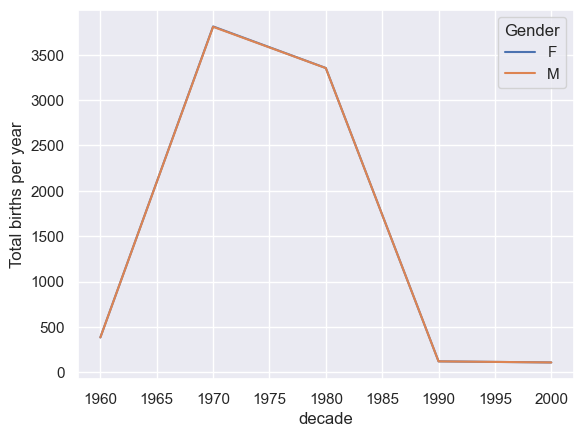

In [147]:
ax = birth_decade.plot()
plt.ylabel("Total births per year")
plt.legend(title="Gender")  
plt.show()

In [148]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
birth_decade = births.pivot_table('births', index='decade', columns='gender', aggfunc='sum')
birth_decade.head()
birth_decade.reset_index()

gender,decade,F,M
0,1960,1753634,1846572
1,1970,16263075,17121550
2,1980,18310351,19243452
3,1990,19479454,20420553
4,2000,18229309,19106428


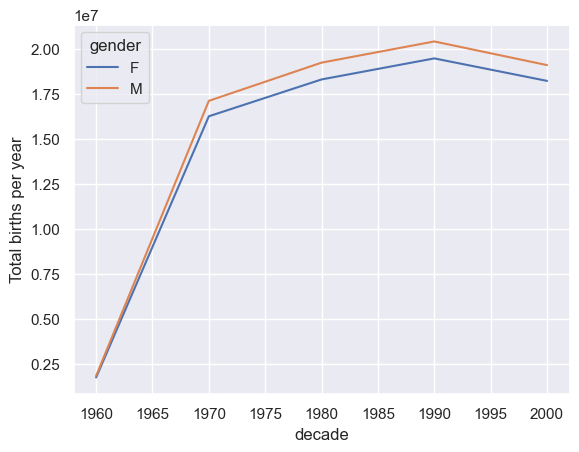

In [149]:
birth_decade.plot()
plt.ylabel("Total births per year")
plt.show()

In [150]:
import numpy as np

quartiles = np.percentile(births['births'], [25, 50, 75])
mean = quartiles[1]
sigma = 0.74 * (quartiles[2] - quartiles[0])

In [151]:
import datetime as dt
births['date'] = pd.to_datetime({
    'year': births['year'],
    'month': births['month'],
    'day': births['day']
}, errors='coerce')
births['day of week'] = births['date'].dt.dayofweek
births.head()

,year,month,day,gender,births,decade,date,day of week
0,1969,1,1,F,4046,1960,1969-01-01,2.0
1,1969,1,1,M,4440,1960,1969-01-01,2.0
2,1969,1,2,F,4454,1960,1969-01-02,3.0
3,1969,1,2,M,4548,1960,1969-01-02,3.0
4,1969,1,3,F,4548,1960,1969-01-03,4.0


In [152]:
births_day = births.pivot_table('births', index='day of week',
                                columns='decade', aggfunc='mean')
births_day.index = ['Mon', 'Tues', 'Wed', 'Thurs', 'Fri', 'Sat', 'Sun']
births_day.head()

decade,1960,1970,1980
Mon,5063.826923,4689.097701,5276.907249
Tues,5286.096154,4885.252399,5503.842553
Wed,5074.622642,4750.376200,5367.642553
Thurs,4978.288462,4696.923372,5333.485106
Fri,5107.884615,4782.095785,5393.087234


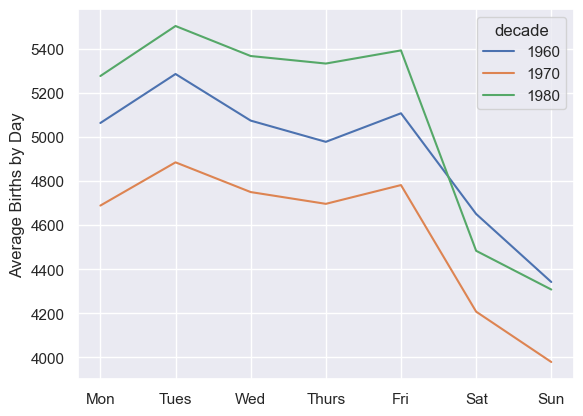

In [153]:
births_day.plot()
plt.ylabel("Average Births by Day")
plt.show()

In [154]:
births_month = births.pivot_table('births', [births['month'], births['day']])
births_month.head()
births_month.reset_index()

,month,day,births
0,1,0,165115.725000
1,1,1,4009.225000
2,1,2,4247.400000
3,1,3,4500.900000
4,1,4,4571.350000
...,...,...,...
391,12,28,5044.200000
392,12,29,5120.150000
393,12,30,5172.350000
394,12,31,4859.200000


In [155]:
def get_valid_day(month, day):
    month_lengths = {1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30, 
                     7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31}
    max_days = month_lengths.get(month, 30)
    if day < 1:
        return 1
    elif day > max_days:
        return max_days
    return day
births_month.index = [pd.Timestamp(year=2012, month=int(month), day=get_valid_day(int(month), int(day)))
                      for (month, day) in births_month.index]
births_month.head()

,births
2012-01-01,165115.725
2012-01-01,4009.225
2012-01-02,4247.400
2012-01-03,4500.900
2012-01-04,4571.350


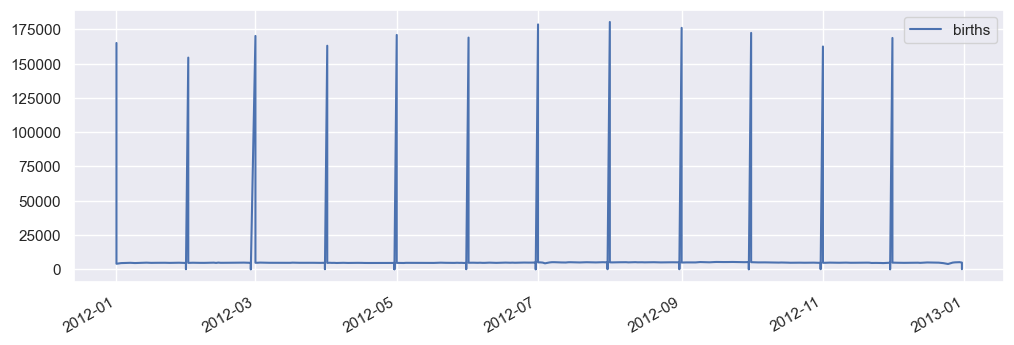

In [156]:
fig, ax = plt.subplots(figsize=(12, 4))
births_month.plot(ax=ax)
plt.show()

In [157]:
import datetime
import pandas as pd

if not isinstance(births.index, pd.DatetimeIndex):
    if 'date' in births.columns: 
        births = births.set_index('date')
        births.index = pd.to_datetime(births.index)
    else:
        print("No date column found. Please specify the date column.")
births_month = births.pivot_table('births', index=[births.index.month, births.index.day])
print(births_month.head())

births_month.index = [datetime.datetime(2012, int(month), int(day))
                      for (month, day) in births_month.index]
print(births_month.head())


             births
date date          
1.0  1.0   4009.225
     2.0   4247.400
     3.0   4500.900
     4.0   4571.350
     5.0   4603.625
              births
2012-01-01  4009.225
2012-01-02  4247.400
2012-01-03  4500.900
2012-01-04  4571.350
2012-01-05  4603.625


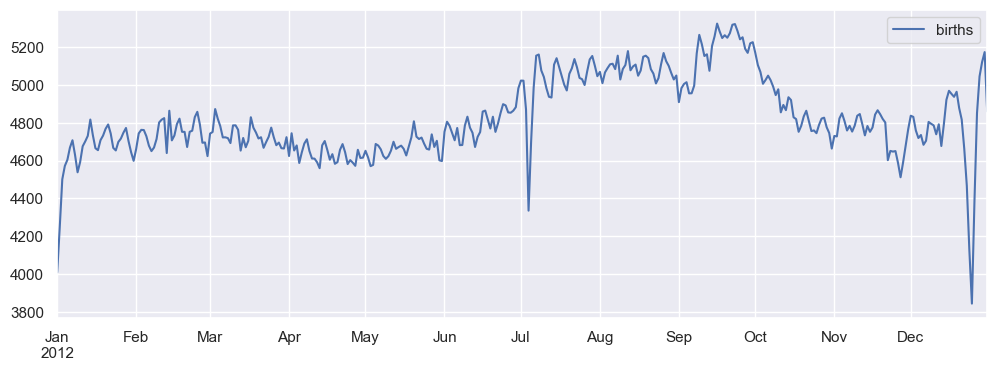

In [158]:
fig, ax = plt.subplots(figsize=(12, 4))
births_month.plot(ax=ax)
plt.show()